# BIOT 6900 · Module 4 Lab, Part 1: Reading a Predicted Structure (Toy Model)

**Runs offline in seconds · no downloads · not graded**

Before you open real AlphaFold files, you practise every skill from the lecture on a **toy protein** whose right answers you know, because we built it:

| Section | Lecture idea |
|---|---|
| 1 · Read pLDDT | Confidence bands; low pLDDT often means disorder (slides 8–9) |
| 2 · Read PAE | Domains, and how sure the arrangement is (slides 10–11) |
| 3 · Check against "experiment" | RMSD; compare confident regions only (slides 16–17) |
| 4 · Score pockets | Druggable pockets; always cross-check confidence (slides 18–19) |

**Our toy protein (150 residues):** domain A (1–60), a flexible linker (61–75), domain B (76–130), and a disordered tail (131–150). The numbers are synthetic but behave like real AlphaFold output.

Uses `numpy`, `pandas` and `matplotlib`. Cells marked **✎ YOUR TURN** ask you to change one value or write one sentence.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(6900)
L = 150
res = np.arange(1, L + 1)                      # residue numbers 1..150
REGIONS = {"Domain A": (1, 60), "Linker": (61, 75), "Domain B": (76, 130), "Tail": (131, 150)}

def region_of(r):
    for name, (a, b) in REGIONS.items():
        if a <= r <= b:
            return name

# Synthetic pLDDT: confident domains, uncertain linker, disordered tail
mean_plddt = {"Domain A": 92, "Linker": 60, "Domain B": 88, "Tail": 35}
spread = {"Domain A": 3, "Linker": 8, "Domain B": 4, "Tail": 8}
plddt = np.array([np.clip(rng.normal(mean_plddt[region_of(r)], spread[region_of(r)]), 0, 100) for r in res])

# Synthetic PAE (expected error in angstroms): low within each domain, high between them and for the tail
def pae_mean(ri, rj):
    a, b = region_of(ri), region_of(rj)
    if a == b == "Domain A": return 3
    if a == b == "Domain B": return 4
    if "Tail" in (a, b): return 27
    if "Linker" in (a, b): return 18
    return 21                                   # Domain A vs Domain B
pae = np.array([[pae_mean(i, j) for j in res] for i in res]) + rng.normal(0, 1.2, (L, L))
pae = np.clip(pae, 0.5, 31.75)

print("Toy protein ready:", L, "residues")
print(pd.DataFrame({"region": [region_of(r) for r in res], "pLDDT": plddt}).groupby("region", sort=False)["pLDDT"].mean().round(1))

Toy protein ready: 150 residues
region
Domain A    92.0
Linker      59.6
Domain B    87.9
Tail        36.4
Name: pLDDT, dtype: float64


## 1 · Read pLDDT

The four bands from lecture slide 8: **> 90** very high, **70–90** confident, **50–70** low, **< 50** very low (often disordered). Colours match the AlphaFold Database.

band
Very high    57
Confident    59
Low          14
Very low     20


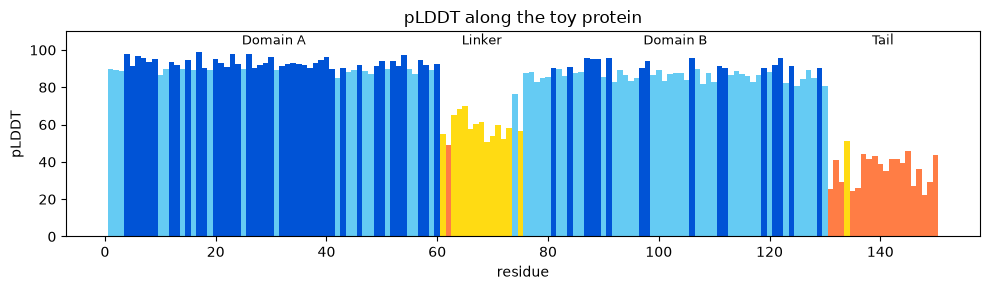

In [2]:
BANDS = [(90, 101, "Very high", "#0053D6"), (70, 90, "Confident", "#65CBF3"),
         (50, 70, "Low", "#FFDB13"), (0, 50, "Very low", "#FF7D45")]

def band(v):
    for lo, hi, name, _ in BANDS:
        if lo <= v < hi:
            return name

df = pd.DataFrame({"residue": res, "region": [region_of(r) for r in res], "pLDDT": plddt.round(1)})
df["band"] = df["pLDDT"].apply(band)
print(df["band"].value_counts().reindex([b[2] for b in BANDS]).fillna(0).astype(int).rename("residues").to_string())

colours = {b[2]: b[3] for b in BANDS}
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(df.residue, df.pLDDT, color=df.band.map(colours), width=1.0)
for name, (a, b) in REGIONS.items():
    ax.text((a + b) / 2, 103, name, ha="center", fontsize=9)
ax.set_ylim(0, 110); ax.set_xlabel("residue"); ax.set_ylabel("pLDDT")
ax.set_title("pLDDT along the toy protein"); plt.tight_layout(); plt.show()

**✎ YOUR TURN:** Which region would you call **disordered**, and why is a low score there *information* rather than a failed prediction? Then run the next cell: what fraction of the protein is below 50?

In [3]:
frac_disordered = (df.pLDDT < 50).mean()
print(f"Fraction of residues with pLDDT < 50: {frac_disordered:.0%}")
# Find contiguous stretches of at least 5 residues below 50
low = (df.pLDDT < 50).values
runs, start = [], None
for i, flag in enumerate(np.append(low, False)):
    if flag and start is None:
        start = i
    elif not flag and start is not None:
        if i - start >= 5:
            runs.append((start + 1, i, i - start))
        start = None
print("Stretches of 5+ residues below 50 (start, end, length):", runs)

Fraction of residues with pLDDT < 50: 13%
Stretches of 5+ residues below 50 (start, end, length): [(135, 150, 16)]


## 2 · Read PAE

PAE[x, y] is the expected error (Å) in the position of residue **x** when the prediction is aligned on residue **y**. Dark = small error. Two dark squares on the diagonal mean two confident domains; light off-diagonal blocks mean their **arrangement** is uncertain (lecture slide 10).

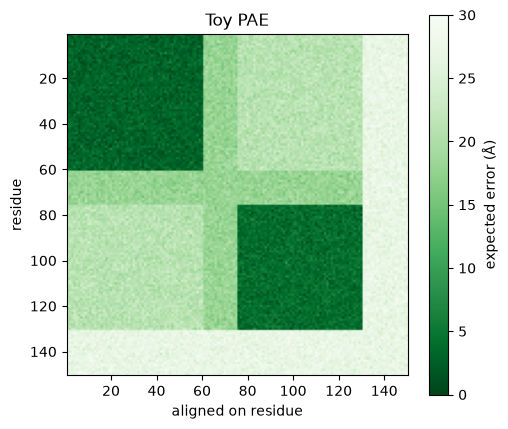

Mean PAE within Domain A : 3.0 Å
Mean PAE within Domain B : 4.0 Å
Mean PAE between A and B : 21.0 Å


In [4]:
fig, ax = plt.subplots(figsize=(5.2, 4.5))
im = ax.imshow(pae, cmap="Greens_r", vmin=0, vmax=30, origin="upper", extent=[0.5, L + 0.5, L + 0.5, 0.5])
plt.colorbar(im, label="expected error (Å)")
ax.set_xlabel("aligned on residue"); ax.set_ylabel("residue"); ax.set_title("Toy PAE")
plt.tight_layout(); plt.show()

def block(a, b):
    (a0, a1), (b0, b1) = REGIONS[a], REGIONS[b]
    return pae[a0 - 1:a1, b0 - 1:b1].mean()
print(f"Mean PAE within Domain A : {block('Domain A', 'Domain A'):.1f} Å")
print(f"Mean PAE within Domain B : {block('Domain B', 'Domain B'):.1f} Å")
print(f"Mean PAE between A and B : {block('Domain A', 'Domain B'):.1f} Å")

### Find the domains automatically

A simple rule: two confident residues (pLDDT ≥ 70) belong to the same domain if the PAE between them is below a cut-off, in both directions. Groups of linked residues are domains.

In [5]:
def find_domains(pae, plddt, pae_cut=8, min_size=10):
    ok = np.where(plddt >= 70)[0]
    linked = (pae[np.ix_(ok, ok)] < pae_cut) & (pae[np.ix_(ok, ok)].T < pae_cut)
    label, current = -np.ones(len(ok), int), 0
    for start in range(len(ok)):                 # simple connected-components search
        if label[start] >= 0:
            continue
        stack = [start]; label[start] = current
        while stack:
            k = stack.pop()
            for m in np.where(linked[k] & (label < 0))[0]:
                label[m] = current; stack.append(m)
        current += 1
    out = []
    for c in range(current):
        members = ok[label == c] + 1             # back to 1-based residue numbers
        if len(members) >= min_size:
            out.append((members.min(), members.max(), len(members)))
    return pd.DataFrame(out, columns=["start", "end", "n_residues"])

PAE_CUT = 8        # ✎ try 3, 8 and 25: what happens to the domains?
print(find_domains(pae, plddt, pae_cut=PAE_CUT))

   start  end  n_residues
0      1   60          60
1     76  130          55


**✎ YOUR TURN:** With `PAE_CUT = 8` you should recover domains A (1–60) and B (76–130). What happens at **3** and at **25**, and why? What does that tell you about choosing thresholds?

## 3 · Check the prediction against an "experimental" structure

Real crystal structures usually **miss disordered regions**: they don't diffract. Our toy "experimental" structure covers residues 1–130 only. In the toy prediction, each domain is almost exact, but **domain B is rotated** relative to A, exactly the uncertainty the PAE warned about.

RMSD (lecture slide 16): superimpose, then take the root-mean-square distance between matching C-alpha atoms.

In [6]:
def helix(n, start, axis_dir, radius=2.3, rise=1.5, phase=0.0):
    t = np.arange(n)
    d = np.asarray(axis_dir, float); d /= np.linalg.norm(d)
    u = np.cross(d, [0, 0, 1.0]); u = u / np.linalg.norm(u) if np.linalg.norm(u) > 1e-6 else np.array([1.0, 0, 0])
    v = np.cross(d, u)
    ang = 2 * np.pi * t / 3.6 + phase
    return start + np.outer(t * rise, d) + radius * (np.outer(np.cos(ang), u) + np.outer(np.sin(ang), v))

def rot(axis, deg):
    a = np.asarray(axis, float); a /= np.linalg.norm(a); th = np.radians(deg)
    K = np.array([[0, -a[2], a[1]], [a[2], 0, -a[0]], [-a[1], a[0], 0]])
    return np.eye(3) + np.sin(th) * K + (1 - np.cos(th)) * K @ K

# "Experimental" coordinates (residues 1-130); the tail is not resolved
A = helix(60, np.zeros(3), [1, 0, 0])
linker = A[-1] + np.cumsum(rng.normal(0, 1.0, (15, 3)) + [0, 2.5, 0], axis=0)
B = helix(55, linker[-1] + [0, 3, 0], [-1, 0.2, 0])
exp_xyz = np.vstack([A, linker, B])

# Prediction: domains almost exact, linker a bit off, domain B rotated 25 degrees about the hinge, tail added
hinge = exp_xyz[74]
pred_A = A + rng.normal(0, 0.4, A.shape)
pred_linker = linker + rng.normal(0, 1.5, linker.shape)
pred_B = (B - hinge) @ rot([0, 0, 1], 25).T + hinge + rng.normal(0, 0.4, B.shape)
pred_tail = pred_B[-1] + np.cumsum(rng.normal(0, 3.0, (20, 3)), axis=0)
pred_xyz = np.vstack([pred_A, pred_linker, pred_B, pred_tail])
print("experimental:", exp_xyz.shape, "| predicted:", pred_xyz.shape)

def kabsch_rmsd(P, Q):
    # RMSD after optimal superposition of P onto Q (both n x 3)
    Pc, Qc = P - P.mean(0), Q - Q.mean(0)
    U, S, Vt = np.linalg.svd(Pc.T @ Qc)
    d = np.sign(np.linalg.det(U @ Vt))
    R = U @ np.diag([1, 1, d]) @ Vt
    return float(np.sqrt(((Pc @ R - Qc) ** 2).sum(1).mean()))

experimental: (130, 3) | predicted: (150, 3)


In [7]:
def rmsd_over(residues):
    idx = np.array(residues) - 1
    return kabsch_rmsd(pred_xyz[idx], exp_xyz[idx])

both = res[res <= 130]                                   # residues present in both structures
confident = both[plddt[both - 1] >= 70]
rows = [("All residues in both (1-130)", both), ("Confident only (pLDDT >= 70)", confident),
        ("Domain A only (1-60)", np.arange(1, 61)), ("Domain B only (76-130)", np.arange(76, 131))]
table = pd.DataFrame([(name, len(r), round(rmsd_over(r), 2)) for name, r in rows],
                     columns=["superimposed on", "residues", "RMSD (Å)"])
print(table.to_string(index=False))

             superimposed on  residues  RMSD (Å)
All residues in both (1-130)       130     10.60
Confident only (pLDDT >= 70)       116     11.07
        Domain A only (1-60)        60      0.67
      Domain B only (76-130)        55      0.68


**✎ YOUR TURN (2–3 sentences):** Why is the RMSD over all confident residues still large, even though each domain on its own is almost perfect? Which part of the PAE plot predicted this? What should you report for a two-domain protein?

## 4 · Score pockets, then cross-check confidence

A pocket finder such as fpocket reports candidate pockets with geometric and chemical features (lecture slides 18–19). Here are five toy pockets, each with the residues that line it. First rank them on **geometry and chemistry alone**.

In [8]:
pockets = pd.DataFrame([
    ("P1", "cleft in Domain A",        520, 0.80, 0.70, list(range(20, 32))),
    ("P2", "groove between A and B",   610, 0.75, 0.65, list(range(52, 60)) + list(range(80, 88))),
    ("P3", "patch in the tail",        700, 0.85, 0.75, list(range(135, 147))),
    ("P4", "shallow dip in Domain B",  250, 0.30, 0.40, list(range(100, 108))),
    ("P5", "pocket in Domain B",       430, 0.65, 0.60, list(range(110, 122))),
], columns=["pocket", "where", "volume_A3", "enclosure", "hydrophobicity", "lining_residues"])

vol = (pockets.volume_A3 - pockets.volume_A3.min()) / (pockets.volume_A3.max() - pockets.volume_A3.min())
pockets["geometry_score"] = (0.4 * vol + 0.3 * pockets.enclosure + 0.3 * pockets.hydrophobicity).round(2)
print("Ranked on geometry and chemistry only:")
print(pockets.sort_values("geometry_score", ascending=False)[["pocket", "where", "volume_A3", "enclosure",
      "hydrophobicity", "geometry_score"]].to_string(index=False))

Ranked on geometry and chemistry only:
pocket                   where  volume_A3  enclosure  hydrophobicity  geometry_score
    P3       patch in the tail        700       0.85            0.75            0.88
    P2  groove between A and B        610       0.75            0.65            0.74
    P1       cleft in Domain A        520       0.80            0.70            0.69
    P5      pocket in Domain B        430       0.65            0.60            0.54
    P4 shallow dip in Domain B        250       0.30            0.40            0.21


Now add the two confidence checks from the slide 11 decision table, using each pocket's lining residues:

* **mean pLDDT** of the lining residues: is the shape real?
* **mean PAE among** the lining residues: are the residues forming the pocket confidently placed **relative to each other**?

In [9]:
def lining_stats(r):
    idx = np.array(r) - 1
    return pd.Series({"mean_pLDDT": plddt[idx].mean(), "mean_PAE_within": pae[np.ix_(idx, idx)].mean()})

pockets = pd.concat([pockets, pockets.lining_residues.apply(lining_stats)], axis=1)

PLDDT_MIN, PAE_MAX = 70, 10      # ✎ the thresholds from the decision table
def verdict(p):
    if p.mean_pLDDT < PLDDT_MIN:
        return "reject: low confidence (likely disordered)"
    if p.mean_PAE_within > PAE_MAX:
        return "suspect: lining residues not confidently placed together"
    return "keep"
pockets["verdict"] = pockets.apply(verdict, axis=1)
print(pockets.sort_values("geometry_score", ascending=False)[["pocket", "where", "geometry_score",
      "mean_pLDDT", "mean_PAE_within", "verdict"]].round(1).to_string(index=False))

pocket                   where  geometry_score  mean_pLDDT  mean_PAE_within                                                  verdict
    P3       patch in the tail             0.9        37.5             27.0               reject: low confidence (likely disordered)
    P2  groove between A and B             0.7        90.6             12.2 suspect: lining residues not confidently placed together
    P1       cleft in Domain A             0.7        93.1              3.1                                                     keep
    P5      pocket in Domain B             0.5        87.7              4.2                                                     keep
    P4 shallow dip in Domain B             0.2        88.0              3.9                                                     keep


**✎ YOUR TURN (2–3 sentences each):**

1. The top two pockets by geometry are **P3** and **P2**. Why does each fail the confidence check, and which rule of the decision table does each break?
2. Which pocket would you take forward, and what would you still want to know before calling the protein "druggable"? (Think of the lecture's limits slide: one snapshot, missing partners, cryptic pockets.)

## Wrap-up: three questions to answer before you leave

Write one or two sentences for each in the cell below.

1. **pLDDT:** What does a stretch of very low pLDDT most often mean, and why does it matter for pocket analysis?
2. **PAE:** A protein has two confident domains but a light off-diagonal PAE block. What can you trust, and what can't you?
3. **Validation:** Why should you superimpose on confident regions, and sometimes on one domain at a time?

**Next:** Part 2 does all of this on real AlphaFold models of p53, APOE and TREM2, and compares p53 with the experimental structure 1TUP.

*Your answers:*